<a href="https://colab.research.google.com/github/Likelipop/01-NLP/blob/main/week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem
- Use BERT and XLNet to classify sentiment from vietnamese students reviews.

## Download dataset
[link text](https://Vietnamese Students' Feedback Corpus (UIT-VSFC) is the resource consists of over 16,000 sentences which are human-annotated with two different tasks: sentiment-based and topic-based classifications.

[1] Kiet Van Nguyen, Vu Duc Nguyen, Phu Xuan-Vinh Nguyen, Tham Thi-Hong Truong, Ngan Luu-Thuy Nguyen, UIT-VSFC: Vietnamese Students' Feedback Corpus for Sentiment Analysis,  2018 10th International Conference on Knowledge and Systems Engineering (KSE 2018), November 1-3, 2018, Ho Chi Minh City, Vietnam

In [1]:
!pip install prettytable

In [2]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [3]:
#Dataset preparation
from datasets import load_dataset
from collections import Counter
#Model
from multiprocessing import Value
from torch.utils.data import Dataset
import torch
from transformers  import AutoTokenizer
# Display
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable

## DATA PREPARATION

## Custom dataset

It is common practice to subclass Pytorch's Dataset and modify it for suitability. The class must contain the following three method:
1. __init__(): This method initializes how our dataset is loaded with a given initial configuration
2. __len__(): This method returns the number of data points in our dataset.

3. __getitem__(): Returns a sample(tensor dictionary) given an index handling tokenization.

In [4]:
import torch
from torch.utils.data import Dataset
from datasets import load_dataset, ClassLabel, DatasetDict, Dataset as HuggingFaceDataset
from transformers import AutoTokenizer, PreTrainedTokenizerBase
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Tuple, Optional, Union, Any

class MyDataset(Dataset):
    """
    A flexible PyTorch Dataset for text classification tasks, designed to work
    with Hugging Face datasets and tokenizers.

    Each instance of this class represents a specific split (e.g., "train", "test").
    """

    def __init__(self,
                 hf_dataset_or_path: Union[str, DatasetDict, HuggingFaceDataset],
                 tokenizer: PreTrainedTokenizerBase,
                 max_length: int,
                 text_column: str = "text", # Default text column name
                 label_column: str = "label", # Default label column name
                 split: Optional[str] = None, # e.g., "train", "test", "validation"
                 label_map: Optional[Dict[str, int]] = None,
                 id_to_label: Optional[Dict[int, str]] = None,
                 num_labels: Optional[int] = None):
        """
        Args:
            hf_dataset_or_path (Union[str, DatasetDict, HuggingFaceDataset]):
                Path/name of the Hugging Face dataset, a pre-loaded DatasetDict,
                or a specific HuggingFaceDataset split.
            tokenizer (PreTrainedTokenizerBase): An initialized Hugging Face tokenizer.
            max_length (int): Maximum sequence length for tokenization.
            text_column (str): The name of the column containing the input text.
            label_column (str): The name of the column containing the labels.
            split (Optional[str]): The specific dataset split to use (e.g., "train").
                If hf_dataset_or_path is already a specific split, this can be None.
            label_map (Optional[Dict[str, int]]): Pre-computed mapping from label names to IDs.
            id_to_label (Optional[Dict[int, str]]): Pre-computed mapping from IDs to label names.
            num_labels (Optional[int]): Pre-computed number of unique labels.
        """
        super().__init__()

        self.tokenizer = tokenizer
        self.max_length = max_length
        self.text_column = text_column
        self.label_column = label_column

        # 1. Load and select the dataset split
        if isinstance(hf_dataset_or_path, str):
            print(f"Loading dataset '{hf_dataset_or_path}'...")
            full_dataset = load_dataset(hf_dataset_or_path)
        elif isinstance(hf_dataset_or_path, (DatasetDict, HuggingFaceDataset)):
            full_dataset = hf_dataset_or_path
        else:
            raise TypeError("hf_dataset_or_path must be a string, DatasetDict, or HuggingFaceDataset.")

        if isinstance(full_dataset, DatasetDict):
            if split is None:
                raise ValueError("A 'split' name (e.g., 'train') must be provided if hf_dataset_or_path is a DatasetDict.")
            if split not in full_dataset:
                raise ValueError(f"Split '{split}' not found in dataset. Available splits: {list(full_dataset.keys())}")
            self.data = full_dataset[split]
            print(f"Using split '{split}' from the dataset.")
        elif isinstance(full_dataset, HuggingFaceDataset):
            self.data = full_dataset # Assume it's already the desired split
            if split:
                print(f"Warning: 'split' argument '{split}' provided but hf_dataset_or_path is already a single HuggingFaceDataset. Using the provided dataset directly.")
            print("Using the provided HuggingFaceDataset split.")
        else:
            # This case should ideally not be reached if the type check above is comprehensive
            raise TypeError("Processed full_dataset is not of expected type.")


        if self.text_column not in self.data.column_names:
            raise ValueError(f"Text column '{self.text_column}' not found. Available columns: {self.data.column_names}")
        if self.label_column not in self.data.column_names:
            raise ValueError(f"Label column '{self.label_column}' not found. Available columns: {self.data.column_names}")

        # 2. Initialize label mapping
        # Priority: Provided maps > HF features > Infer from data
        if label_map and id_to_label and num_labels is not None:
            self.label_to_id = label_map
            self.id_to_label = id_to_label
            self.num_labels = num_labels
            self.label_names = [self.id_to_label[i] for i in range(self.num_labels)]
            print("Using pre-computed label mappings.")
        else:
            self._initialize_label_properties()
            print(f"Initialized label properties: {self.num_labels} labels - {self.label_names}")

    def _initialize_label_properties(self):
        """Helper to initialize label_to_id, id_to_label, and num_labels."""
        feature_info = self.data.features[self.label_column]
        if isinstance(feature_info, ClassLabel):
            self.label_names = feature_info.names
            self.label_to_id = {name: i for i, name in enumerate(self.label_names)}
            self.id_to_label = {i: name for i, name in enumerate(self.label_names)}
            self.num_labels = feature_info.num_classes
            print(f"Inferred labels from ClassLabel feature: '{self.label_column}'")
        else:
            # Infer from unique values if not a ClassLabel (e.g., plain integers or strings)
            print(f"Warning: Label column '{self.label_column}' is not a ClassLabel. Attempting to infer labels from unique values.")
            unique_labels = sorted(list(set(self.data[self.label_column])))

            if not unique_labels:
                raise ValueError(f"No unique labels found in column '{self.label_column}'. The column might be empty or contain only one value not yet processed.")

            # Check if labels are already integers (0, 1, ..., N-1)
            if all(isinstance(label, int) for label in unique_labels) and \
               all(0 <= label < len(unique_labels) for label in unique_labels) and \
               len(set(unique_labels)) == max(unique_labels) + 1: # Contiguous integers starting from 0
                self.label_names = [str(i) for i in unique_labels] # Use string representation of these ints as names
                self.id_to_label = {i: str(i) for i in unique_labels}
                self.label_to_id = {str(i): i for i in unique_labels}
                self.num_labels = len(unique_labels)
                print(f"Labels appear to be contiguous integers. Inferred {self.num_labels} labels: {self.label_names}")
            else: # Assume string labels or non-contiguous ints that need mapping
                self.label_names = [str(label) for label in unique_labels] # Ensure all are strings
                self.label_to_id = {name: i for i, name in enumerate(self.label_names)}
                self.id_to_label = {i: name for i, name in enumerate(self.label_names)}
                self.num_labels = len(self.label_names)
                print(f"Inferred {self.num_labels} labels by unique values: {self.label_names}")


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        sample = self.data[idx]
        text = sample[self.text_column]
        label_val = sample[self.label_column]

        # Process label
        if isinstance(label_val, str):
            if label_val not in self.label_to_id:
                raise ValueError(f"Unknown string label '{label_val}'. Known labels: {list(self.label_to_id.keys())}")
            label_id = self.label_to_id[label_val]
        elif isinstance(label_val, int):
            # If labels were inferred as int strings (e.g. "0", "1") but data has ints (0,1)
            if str(label_val) in self.label_to_id:
                label_id = self.label_to_id[str(label_val)]
            # If labels were ClassLabel (already int) or directly mapped ints
            elif label_val in self.id_to_label: # Check if the int is a valid ID
                label_id = label_val
            else:
                raise ValueError(f"Integer label {label_val} is out of bounds or not in id_to_label map. Known IDs: {list(self.id_to_label.keys())}")
        else:
            raise TypeError(f"Unsupported label type: {type(label_val)}. Expected str or int.")

        # Tokenize text
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label_id, dtype=torch.long)
        }

    def get_label_distribution(self) -> Counter:
        """Computes and returns the distribution of labels in this dataset split."""
        labels_in_split = []
        for i in range(len(self)):
            sample = self.data[i]
            label_val = sample[self.label_column]
            if isinstance(label_val, str):
                labels_in_split.append(label_val)
            elif isinstance(label_val, int):
                # Map int back to string name for consistent counting
                if label_val in self.id_to_label:
                    labels_in_split.append(self.id_to_label[label_val])
                elif str(label_val) in self.label_names: # If label names were "0", "1" etc.
                    labels_in_split.append(str(label_val))
                else:
                    # This should not happen if __getitem__ and _initialize_label_properties are correct
                    labels_in_split.append(f"UNKNOWN_INT_LABEL_{label_val}")
            else:
                labels_in_split.append(f"UNKNOWN_TYPE_LABEL_{str(label_val)}")

        return Counter(labels_in_split)


## Visualization

<h4>Define the plot function</h4>

In [5]:
# --- Visualization Function (Separate from the Dataset class) ---

def plot_label_distributions(
    datasets_info: List[Tuple[MyDataset, str]],
    figsize: Tuple[int, int] = (12, 6),
    title: str = "Label Distribution"
):
    """
    Plots the label distribution for one or more MyDataset instances.

    Args:
        datasets_info (List[Tuple[MyDataset, str]]):
            A list of tuples, where each tuple contains a MyDataset instance
            and a string name for that dataset (e.g., "Train Set", "Test Set").
        figsize (Tuple[int, int]): Size of the plot.
        title (str): Overall title for the plot.
    """
    if not datasets_info:
        print("No datasets provided for visualization.")
        return

    num_datasets = len(datasets_info)
    # Use label names from the first dataset as the canonical order for categories
    # Assumes all datasets share the same label scheme or are comparable.
    canonical_label_names = datasets_info[0][0].label_names

    # If there are string numbers as label names, sort them numerically for better plotting
    try:
        if all(name.isdigit() for name in canonical_label_names):
            canonical_label_names = sorted(canonical_label_names, key=int)
    except: # In case of mixed types or other issues, keep original order
        pass


    label_counts_per_dataset = []
    dataset_plot_names = []

    for dataset_instance, dataset_name in datasets_info:
        if not isinstance(dataset_instance, MyDataset):
            print(f"Warning: Item '{dataset_name}' is not a MyDataset instance. Skipping.")
            continue

        # Ensure consistency with canonical_label_names
        if set(dataset_instance.label_names) != set(canonical_label_names):
             print(f"Warning: Label names for '{dataset_name}' ({dataset_instance.label_names}) "
                   f"differ from canonical names ({canonical_label_names}). Visualization might be misleading.")

        dist = dataset_instance.get_label_distribution()
        counts = [dist.get(label, 0) for label in canonical_label_names]
        label_counts_per_dataset.append(counts)
        dataset_plot_names.append(dataset_name)

    if not label_counts_per_dataset:
        print("No valid dataset distributions to plot.")
        return

    num_categories = len(canonical_label_names)
    x = np.arange(num_categories) # the label locations

    if num_datasets == 1: # Single bar chart
        fig, ax = plt.subplots(figsize=figsize)
        ax.bar(x, label_counts_per_dataset[0], label=dataset_plot_names[0])
        ax.set_ylabel('Counts')
        ax.set_title(f"{dataset_plot_names[0]} - {title}")
        ax.set_xticks(x)
        ax.set_xticklabels(canonical_label_names, rotation=45, ha="right")
        ax.legend()
    else: # Grouped bar chart
        width = 0.8 / num_datasets  # the width of the bars
        fig, ax = plt.subplots(figsize=figsize)
        for i, (counts, name) in enumerate(zip(label_counts_per_dataset, dataset_plot_names)):
            offset = width * (i - (num_datasets - 1) / 2)
            ax.bar(x + offset, counts, width, label=name)

        ax.set_ylabel('Counts')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(canonical_label_names, rotation=45, ha="right")
        ax.legend()

    plt.tight_layout()
    plt.show()

<h4>Define dataset config</h4>

In [6]:
from transformers import AutoTokenizer
from datasets import load_dataset
from prettytable import PrettyTable, ALL # For table borders
import torch # For checking tensor types in sample


# ============================
# ==INITIALIZE CONFIG=========
# ============================

# 1. Define dataset parameters
dataset_path = "uitnlp/vietnamese_students_feedback"
tokenizer_name = "vinai/phobert-base"
max_seq_length = 128

# For "uitnlp/vietnamese_students_feedback", the text column is "sentence"
# The user's snippet had "sentence", which would cause an error. Corrected here.
text_col = "sentence"
label_col = "sentiment" # This is correct for the dataset

config_table = PrettyTable()
config_table.field_names = ["Parameter", "Value"]
config_table.align["Parameter"] = "l"
config_table.align["Value"] = "l"
config_table.add_row(["Dataset Path", dataset_path])
config_table.add_row(["Tokenizer Name", tokenizer_name])
config_table.add_row(["Max Sequence Length", max_seq_length])
config_table.add_row(["Text Column", text_col])
config_table.add_row(["Label Column", label_col])
print("\nConfiguration Parameters:")
print(config_table)

# 2. Initialize tokenizer
print(f"\nLoading tokenizer: {tokenizer_name}...")
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
print("Tokenizer loaded successfully.")


<ipython-input-6-35856ee53823>:3: DeprecationWarning: the 'ALL' constant is deprecated, use the 'HRuleStyle' and 'VRuleStyle' enums instead
  from prettytable import PrettyTable, ALL # For table borders



Configuration Parameters:
+---------------------+-------------------------------------+
| Parameter           | Value                               |
+---------------------+-------------------------------------+
| Dataset Path        | uitnlp/vietnamese_students_feedback |
| Tokenizer Name      | vinai/phobert-base                  |
| Max Sequence Length | 128                                 |
| Text Column         | sentence                            |
| Label Column        | sentiment                           |
+---------------------+-------------------------------------+

Loading tokenizer: vinai/phobert-base...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

Tokenizer loaded successfully.


#Load data from pre-defined config

In [7]:
# 3. Load full Hugging Face dataset
print(f"\nLoading full dataset from Hugging Face Hub: {dataset_path}...")
full_hf_dataset = load_dataset(dataset_path) # This returns a DatasetDict
print("Full dataset loaded successfully.")
print(f"Available splits in loaded dataset: {list(full_hf_dataset.keys())}")

datasets_to_plot = []
dataset_splits_info = {} # To store info for each split

# Process each split
splits_to_process = ["train", "validation", "test"]

for split_name in splits_to_process:
    print(f"\n--- Processing '{split_name.capitalize()}' Dataset ---")

    current_mydataset = MyDataset(
        hf_dataset_or_path=full_hf_dataset, # Pass the pre-loaded DatasetDict
        tokenizer=tokenizer,
        max_length=max_seq_length,
        text_column=text_col,
        label_column=label_col,
        split=split_name
    )
    datasets_to_plot.append((current_mydataset, f"{split_name.capitalize()} Split"))

    split_info_table = PrettyTable()
    split_info_table.field_names = ["Property", "Value"]
    split_info_table.align["Property"] = "l"
    split_info_table.align["Value"] = "l"
    split_info_table.add_row([f"{split_name.capitalize()} Dataset Size", len(current_mydataset)])
    split_info_table.add_row(["Number of Labels", current_mydataset.num_labels])
    split_info_table.add_row(["Label Names", ", ".join(current_mydataset.label_names)])
    print(split_info_table)

    # Store for later access if needed, e.g. train_mydataset
    dataset_splits_info[split_name] = current_mydataset

    # For the 'train' split, show more detailed sample and distribution (as in original)
    if split_name == "train":
        train_mydataset = current_mydataset # Keep a reference for potential direct use later

        # Sample Item Details
        print("\nSample Item from Training Data:")
        sample_idx = 0
        raw_sample = full_hf_dataset[split_name][sample_idx]
        processed_sample = train_mydataset[sample_idx]

        sample_table = PrettyTable()
        sample_table.hrules = ALL # Add horizontal lines between all rows
        sample_table.field_names = ["Detail", "Value"]
        sample_table.align["Detail"] = "l"
        sample_table.align["Value"] = "l"

        original_text = raw_sample[text_col]
        max_text_display_len = 70
        display_text = (original_text[:max_text_display_len] + '...') if len(original_text) > max_text_display_len else original_text

        sample_table.add_row(["Original Text (truncated)", display_text])
        sample_table.add_row(["Original Label (raw)", raw_sample[label_col]])

        processed_label_id = processed_sample['labels'].item()
        processed_label_name = train_mydataset.id_to_label.get(processed_label_id, "N/A")
        sample_table.add_row(["Processed Label ID", processed_label_id])
        sample_table.add_row(["Processed Label Name", processed_label_name])

        sample_table.add_row(["Input IDs Shape", str(processed_sample['input_ids'].shape)])
        sample_table.add_row(["Attention Mask Shape", str(processed_sample['attention_mask'].shape)])
        # sample_table.add_row(["Input IDs (first 10)", str(processed_sample['input_ids'][:10].tolist())]) # Optional: show some token IDs
        print(sample_table)

        # Label Distribution for Training Data
        print("\nTraining Data Label Distribution:")
        distribution = train_mydataset.get_label_distribution()
        dist_table = PrettyTable()
        dist_table.field_names = ["Label Name", "Count", "Percentage"]
        dist_table.align["Label Name"] = "l"
        dist_table.align["Count"] = "r"
        dist_table.align["Percentage"] = "r"

        total_samples = len(train_mydataset)
        # Use canonical_label_names from the dataset for consistent order
        for label_name in train_mydataset.label_names:
            count = distribution.get(label_name, 0)
            percentage = f"{(count / total_samples * 100):.2f}%" if total_samples > 0 else "N/A"
            dist_table.add_row([label_name, count, percentage])
        dist_table.sortby = "Count"
        dist_table.reversesort = True
        print(dist_table)



Loading full dataset from Hugging Face Hub: uitnlp/vietnamese_students_feedback...


README.md:   0%|          | 0.00/4.79k [00:00<?, ?B/s]

vietnamese_students_feedback.py:   0%|          | 0.00/4.97k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/475k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/63.3k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/134k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1583 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3166 [00:00<?, ? examples/s]

Full dataset loaded successfully.
Available splits in loaded dataset: ['train', 'validation', 'test']

--- Processing 'Train' Dataset ---
Using split 'train' from the dataset.
Inferred labels from ClassLabel feature: 'sentiment'
Initialized label properties: 3 labels - ['negative', 'neutral', 'positive']
+--------------------+-----------------------------+
| Property           | Value                       |
+--------------------+-----------------------------+
| Train Dataset Size | 11426                       |
| Number of Labels   | 3                           |
| Label Names        | negative, neutral, positive |
+--------------------+-----------------------------+

Sample Item from Training Data:
+---------------------------+---------------------------+
| Detail                    | Value                     |
+---------------------------+---------------------------+
| Original Text (truncated) | slide giáo trình đầy đủ . |
+---------------------------+---------------------------+


#Visualize dataset's distribution



--- Plotting Label Distributions ---


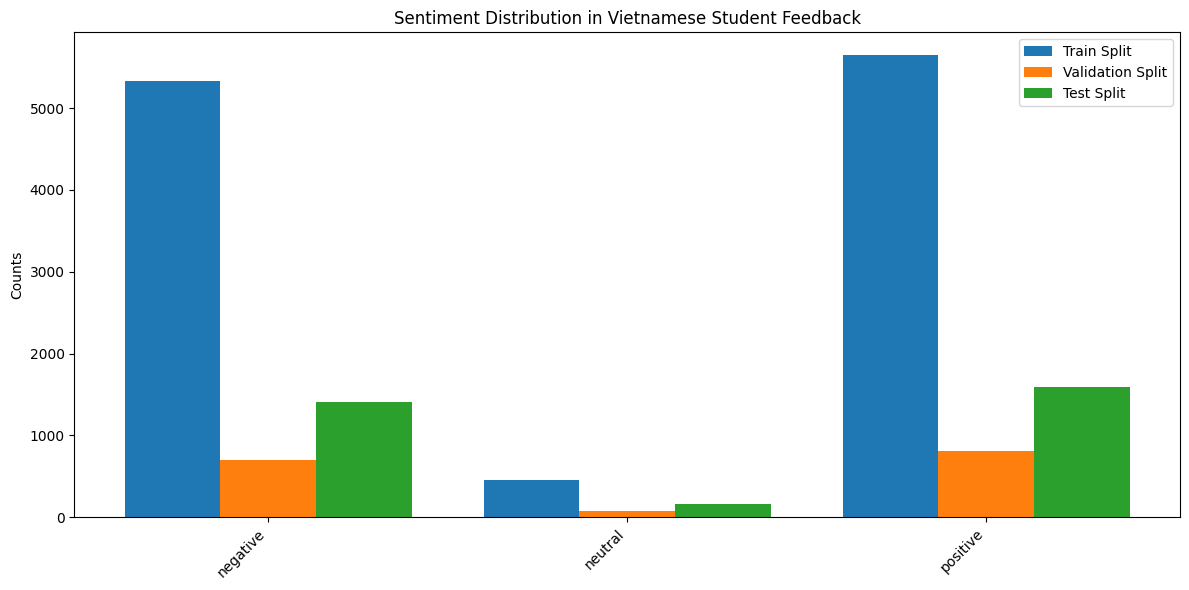

In [8]:
# 4. Using plot_label_distributions (This part remains non-tabular as it's graphical)
if datasets_to_plot:
    print("\n\n--- Plotting Label Distributions ---")
    plot_label_distributions(
        datasets_info=datasets_to_plot,
        title="Sentiment Distribution in Vietnamese Student Feedback"
    )
else:
    print("\nNo datasets were processed to plot.")

    # Example: Plotting only the training set distribution (if train_mydataset exists)
    # if "train" in dataset_splits_info:
    #     print("\n--- Plotting Only Training Set Label Distribution ---")
    #     plot_label_distributions(
    #         datasets_info=[(dataset_splits_info["train"], "Train Split (uitnlp/vietnamese_students_feedback)")],
    #         title="Sentiment Distribution (Train)"
    #     )

In [9]:
from torch.utils.data import DataLoader

# Define batch size
batch_size = 32 # You can adjust this value

# Prepare DataLoaders
# Get the MyDataset instances created in the previous code block
train_dataset = dataset_splits_info["train"]
validation_dataset = dataset_splits_info["validation"]
test_dataset = dataset_splits_info["test"]

# Create DataLoaders for each split
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nCreated DataLoaders with batch size {batch_size}:")
print(f"- Training DataLoader size: {len(train_dataloader)} batches")
print(f"- Validation DataLoader size: {len(validation_dataloader)} batches")
print(f"- Test DataLoader size: {len(test_dataloader)} batches")

# Optional: Inspect a batch from the training dataloader
print("\nInspecting a sample batch from the Training DataLoader:")
sample_batch = next(iter(train_dataloader))

batch_sample_table = PrettyTable()
batch_sample_table.field_names = ["Tensor Name", "Shape", "Dtype"]
batch_sample_table.align["Tensor Name"] = "l"
batch_sample_table.align["Shape"] = "l"
batch_sample_table.align["Dtype"] = "l"

for key, tensor in sample_batch.items():
    batch_sample_table.add_row([key, str(tensor.shape), str(tensor.dtype)])

print(batch_sample_table)


Created DataLoaders with batch size 32:
- Training DataLoader size: 358 batches
- Validation DataLoader size: 50 batches
- Test DataLoader size: 99 batches

Inspecting a sample batch from the Training DataLoader:
+----------------+-----------------------+-------------+
| Tensor Name    | Shape                 | Dtype       |
+----------------+-----------------------+-------------+
| input_ids      | torch.Size([32, 128]) | torch.int64 |
| attention_mask | torch.Size([32, 128]) | torch.int64 |
| labels         | torch.Size([32])      | torch.int64 |
+----------------+-----------------------+-------------+


In [10]:
# Function to check for labels outside the range [0, 2]
def check_label_range(dataset: MyDataset):
    """
    Checks if any labels in the dataset are outside the range [0, 2].

    Args:
        dataset (MyDataset): The custom dataset instance to check.

    Returns:
        bool: True if any label is outside [0, 2], False otherwise.
        list: A list of unique labels found outside the range [0, 2].
    """
    out_of_range_labels = set()
    for i in range(len(dataset)):
        sample = dataset[i]
        label = sample['labels'].item() # Get the integer label ID

        if label < 0 or label > 2:
            out_of_range_labels.add(label)

    if out_of_range_labels:
        print(f"Warning: Found labels outside the range [0, 2]: {sorted(list(out_of_range_labels))}")
        return True, sorted(list(out_of_range_labels))
    else:
        print("All labels are within the range [0, 2].")
        return False, []

# Check the label range for each dataset split
print("\n--- Checking Label Range [0, 2] ---")

# Assuming dataset_splits_info dictionary contains your loaded datasets
if 'train' in dataset_splits_info:
    print("\nChecking Train Dataset:")
    check_label_range(dataset_splits_info['train'])

if 'validation' in dataset_splits_info:
    print("\nChecking Validation Dataset:")
    check_label_range(dataset_splits_info['validation'])

if 'test' in dataset_splits_info:
    print("\nChecking Test Dataset:")
    check_label_range(dataset_splits_info['test'])



--- Checking Label Range [0, 2] ---

Checking Train Dataset:
All labels are within the range [0, 2].

Checking Validation Dataset:
All labels are within the range [0, 2].

Checking Test Dataset:
All labels are within the range [0, 2].


In [11]:
from torch import nn
from transformers import AutoModel, AutoConfig
import torch # Import torch here if not already imported

class BertForSequenceClassification(nn.Module):
    def __init__(self, model_name, num_labels):
        """
        Initializes the BertForSequenceClassification model.

        Args:
            model_name (str): The name of the pre-trained BERT model (e.g., 'bert-base-uncased').
            num_labels (int): The number of classes for the classification task.
        """
        super().__init__()
        config = AutoConfig.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name)
        # The output of BERT's pooler layer is a fixed-size vector (typically 768 for base models)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_labels)
        self.dropout = nn.Dropout(self.bert.config.hidden_dropout_prob) # Optional: Add dropout

    # Add token_type_ids parameter to the forward method
    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        """
        Forward pass for the model.

        Args:
            input_ids (torch.Tensor): Tokenized input IDs. Shape (batch_size, sequence_length).
            attention_mask (torch.Tensor, optional): Attention mask. Shape (batch_size, sequence_length).
                                                    Defaults to None.
            token_type_ids (torch.Tensor, optional): Token type IDs (segment IDs). Shape (batch_size, sequence_length).
                                                    Defaults to None.
            labels (torch.Tensor, optional): Ground truth labels. Shape (batch_size,).
                                            Used for computing loss. Defaults to None.

        Returns:
            tuple: A tuple containing:
                - logits (torch.Tensor): The output logits from the classifier.
                                        Shape (batch_size, num_labels).
                - loss (torch.Tensor, optional): The loss if labels are provided.
                                                 Defaults to None.
        """
        # Pass token_type_ids to the bert model call
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        pooled_output = outputs.pooler_output

        # Apply dropout before the classifier layer
        pooled_output = self.dropout(pooled_output)

        # Pass through the classifier layer
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return logits, loss

In [12]:
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler # For mixed precision
from tqdm.notebook import tqdm # For progress bar
import torch.nn.functional as F

def evaluate(model, dataloader, device):
    """
    Evaluates the model on a given dataloader.

    Args:
        model (nn.Module): The model to evaluate.
        dataloader (DataLoader): The DataLoader for the evaluation data.
        device (torch.device): The device (CPU or GPU) to run evaluation on.

    Returns:
        tuple: A tuple containing the average loss and accuracy.
    """
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    # Lists to store predicted and true labels for detailed metrics later
    all_predictions = []
    all_true_labels = []

    # Use torch.no_grad() to disable gradient calculation during evaluation
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            logits, loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            total_loss += loss.item()
            total_samples += labels.size(0)

            # Get predictions
            _, predicted_labels = torch.max(logits, dim=1)
            correct_predictions += (predicted_labels == labels).sum().item()

            # Store predictions and true labels
            all_predictions.extend(predicted_labels.cpu().tolist())
            all_true_labels.extend(labels.cpu().tolist())


    avg_loss = total_loss / len(dataloader) if len(dataloader) > 0 else 0
    accuracy = correct_predictions / total_samples if total_samples > 0 else 0

    return avg_loss, accuracy, all_true_labels, all_predictions

def train(model, train_dataloader, val_dataloader, epochs, optimizer, device, scaler=None):
    """
    Trains the model for a specified number of epochs.

    Args:
        model (nn.Module): The model to train.
        train_dataloader (DataLoader): The DataLoader for the training data.
        val_dataloader (DataLoader): The DataLoader for the validation data.
        epochs (int): The number of training epochs.
        optimizer (optim.Optimizer): The optimizer to use.
        device (torch.device): The device (CPU or GPU) to run training on.
        scaler (GradScaler, optional): GradScaler for mixed precision training. Defaults to None.

    Returns:
        dict: A dictionary containing training and validation loss and accuracy histories.
    """
    model.to(device) # Move model to the specified device

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    print(f"Starting training for {epochs} epochs...")

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        total_train_loss = 0
        correct_train_predictions = 0
        total_train_samples = 0

        train_loop = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} Training")

        for batch in train_loop:
            optimizer.zero_grad() # Clear previous gradients

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            if scaler: # Use mixed precision if scaler is provided
                with autocast():
                    logits, loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else: # Standard training
                logits, loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss.backward() # Backpropagation
                optimizer.step() # Update weights

            total_train_loss += loss.item()
            total_train_samples += labels.size(0)
            _, predicted_labels = torch.max(logits, dim=1)
            correct_train_predictions += (predicted_labels == labels).sum().item()

            train_loop.set_postfix(loss=loss.item())


        avg_train_loss = total_train_loss / len(train_dataloader) if len(train_dataloader) > 0 else 0
        train_accuracy = correct_train_predictions / total_train_samples if total_train_samples > 0 else 0

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)

        # --- Validation Phase ---
        # Evaluate on the validation set
        avg_val_loss, val_accuracy, _, _ = evaluate(model, val_dataloader, device)

        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_accuracy)

        print(f"\nEpoch {epoch+1}/{epochs} Completed:")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
        print(f"Val Loss:   {avg_val_loss:.4f}, Val Acc:   {val_accuracy:.4f}")
        print("-" * 30)


    print("Training finished.")
    return history



In [13]:
train_dataset.num_labels

3

In [14]:
import matplotlib.pyplot as plt
# Example usage (assuming model, dataloaders, and optimizer are defined)

# Determine the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Initialize the model
# Assuming num_labels was determined from the dataset initialization
# Corrected model_name to match the PhoBERT tokenizer used
model_name = "vinai/phobert-base"
num_labels = train_dataset.num_labels # Get from the dataset instance

print(f"Initializing model '{model_name}' with {num_labels} labels...")
# Pass the correct model_name to the model initialization
model = BertForSequenceClassification(model_name=model_name, num_labels=num_labels)

# Count trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {count_parameters(model):,}")


# Define optimizer
# Example using AdamW, a common choice for Transformer models
optimizer = optim.AdamW(model.parameters(), lr=5e-5) # Learning rate might need tuning

# Optional: Initialize GradScaler for mixed precision training (highly recommended for GPU)
# Mixed precision can speed up training and reduce memory usage
# scaler = GradScaler() # Uncomment this line to enable mixed precision
scaler = None # Comment this line out if you uncomment the above line

# Set number of training epochs
num_epochs = 3 # Adjust as needed

# Start the training process
training_history = train(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=validation_dataloader,
    epochs=num_epochs,
    optimizer=optimizer,
    device=device,
    scaler=scaler # Pass the scaler (or None if not using mixed precision)
)

print("\nTraining History:")
history_table = PrettyTable()
history_table.field_names = ["Epoch", "Train Loss", "Train Acc", "Val Loss", "Val Acc"]
history_table.align["Epoch"] = "r"
for i in range(num_epochs):
    history_table.add_row([
        i + 1,
        f"{training_history['train_loss'][i]:.4f}",
        f"{training_history['train_acc'][i]:.4f}",
        f"{training_history['val_loss'][i]:.4f}",
        f"{training_history['val_acc'][i]:.4f}"
    ])
print(history_table)


# Optional: Plotting history (requires matplotlib)
if 'matplotlib' in globals() and 'plt' in globals():
    print("\nPlotting Training/Validation History...")
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), training_history['train_loss'], label='Train Loss')
    plt.plot(range(1, num_epochs + 1), training_history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), training_history['train_acc'], label='Train Accuracy')
    plt.plot(range(1, num_epochs + 1), training_history['val_acc'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("\nMatplotlib not available. Skipping history plot.")


# --- Final Evaluation on Test Set ---
print("\n--- Evaluating on Test Set ---")
test_loss, test_accuracy, test_true_labels, test_predictions = evaluate(model, test_dataloader, device)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Optional: Compute more detailed metrics like Classification Report (requires sklearn)
try:
    from sklearn.metrics import classification_report
    print("\nClassification Report:")
    print(classification_report(test_true_labels, test_predictions, target_names=test_dataset.label_names)) # Use label names for report
except ImportError:
    print("\nscikit-learn not installed. Skipping classification report.")


Using device: cuda
Initializing model 'vinai/phobert-base' with 3 labels...


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Number of trainable parameters: 135,000,579


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Starting training for 3 epochs...


...

Epoch 3/3 Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]


Epoch 3/3 Completed:
Train Loss: 0.1806, Train Acc: 0.9412
Val Loss:   0.2206, Val Acc:   0.9318
------------------------------
Training finished.

Training History:
+-------+------------+-----------+----------+---------+
| Epoch | Train Loss | Train Acc | Val Loss | Val Acc |
+-------+------------+-----------+----------+---------+
|     1 |   0.2724   |   0.9104  |  0.2229  |  0.9349 |
|     2 |   0.2261   |   0.9248  |  0.2088  |  0.9337 |
|     3 |   0.1806   |   0.9412  |  0.2206  |  0.9318 |
+-------+------------+-----------+----------+---------+

Matplotlib not available. Skipping history plot.

--- Evaluating on Test Set ---


Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]


Test Loss: 0.2581
Test Accuracy: 0.9141

Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.95      0.94      1409
     neutral       0.67      0.26      0.37       167
    positive       0.91      0.95      0.93      1590

    accuracy                           0.91      3166
   macro avg       0.84      0.72      0.75      3166
weighted avg       0.91      0.91      0.90      3166



# Question:

For both BERT - XLNet and vietnamese texts (this homework) and english texts (previous homework):
- Are there any differences in the evaluating performance in applying those 2 models for 2 datasets, i.e., vietnamese and english ? Analyze and visualize your results to prove your conclusion.
- How to improve the weaker approaches ?